# Predicting Numbness Using Health Data

## Overview
This project uses health and nutritional data to predict whether a person experiences numbness and tingling using machine learning.

## Data
The dataset includes vitamin levels, BMI, age, and health symptoms for 4000 individuals.

## Analysis
Lower vitamin B12 levels were strongly associated with numbness based on exploratory data analysis.

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline

df = pd.read_csv("vitamin_deficiency_disease_dataset_20260123.csv")

In [99]:
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,has_multiple_deficiencies
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,...,0,0,0,0,0,0,0,0,Healthy,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,0,0,0,1,0,0,0,0,Rickets_Osteomalacia,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,1,0,0,0,0,0,0,0,Healthy,0
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,0,0,0,0,0,1,1,0,Anemia,0
4,63,Male,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,...,0,0,0,0,0,0,0,0,Healthy,0


In [100]:
df["has_numbness_tingling"] = df["has_numbness_tingling"].astype(int)

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        4000 non-null   int64  
 1   gender                     4000 non-null   str    
 2   bmi                        4000 non-null   float64
 3   smoking_status             4000 non-null   str    
 4   alcohol_consumption        2722 non-null   str    
 5   exercise_level             4000 non-null   str    
 6   diet_type                  4000 non-null   str    
 7   sun_exposure               4000 non-null   str    
 8   income_level               4000 non-null   str    
 9   latitude_region            4000 non-null   str    
 10  vitamin_a_percent_rda      4000 non-null   float64
 11  vitamin_c_percent_rda      4000 non-null   float64
 12  vitamin_d_percent_rda      4000 non-null   float64
 13  vitamin_e_percent_rda      4000 non-null   float64
 14  vit

In [102]:
df.describe()

,age,bmi,vitamin_a_percent_rda,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,...,symptoms_count,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,has_multiple_deficiencies
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,50.766250,26.105325,90.770850,89.199075,72.216388,89.946125,62.743225,90.382275,82.586300,76.211125,...,1.86725,0.102250,0.269250,0.043500,0.300750,0.265750,0.351250,0.303000,0.161750,0.347250
std,19.306237,4.922746,37.083534,37.505809,42.831000,37.444649,37.396636,37.563684,36.359131,33.226984,...,1.79581,0.303015,0.443626,0.204005,0.458641,0.441787,0.477421,0.459613,0.368267,0.476156
min,18.000000,15.000000,10.000000,10.000000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.000000,22.800000,62.600000,60.975000,40.730000,61.700000,32.700000,61.800000,55.600000,51.400000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,51.000000,26.200000,85.500000,83.500000,62.270000,84.050000,55.600000,84.800000,77.100000,71.250000,...,2.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,67.000000,29.400000,115.300000,113.000000,93.317500,114.100000,84.500000,115.200000,105.300000,95.900000,...,3.00000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,84.000000,45.000000,219.000000,250.000000,275.600000,237.600000,243.600000,226.600000,232.700000,211.400000,...,9.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [103]:
df[["vitamin_b12_percent_rda","has_numbness_tingling"]].head()

,vitamin_b12_percent_rda,has_numbness_tingling
0,102.5,0
1,62.6,0
2,136.2,0
3,31.8,1
4,72.6,0


In [104]:
df.groupby("has_numbness_tingling")["vitamin_b12_percent_rda"].mean()

has_numbness_tingling
0    80.206435
1    30.489110
Name: vitamin_b12_percent_rda, dtype: float64

In [105]:
df["has_numbness_tingling"].value_counts()

has_numbness_tingling
0    2595
1    1405
Name: count, dtype: int64

In [106]:
df["b12_risk"] = df["vitamin_b12_percent_rda"] < 50
df[["vitamin_b12_percent_rda", "b12_risk", "has_numbness_tingling"]].head(10)

,vitamin_b12_percent_rda,b12_risk,has_numbness_tingling
0,102.5,False,0
1,62.6,False,0
2,136.2,False,0
3,31.8,True,1
4,72.6,False,0
5,21.2,True,1
6,27.0,True,0
7,50.0,False,0
8,122.8,False,0
9,125.9,False,0


In [107]:
df.groupby("b12_risk")["has_numbness_tingling"].mean()

b12_risk
False    0.000000
True     0.798295
Name: has_numbness_tingling, dtype: float64

In [108]:
df.groupby("has_fatigue")["iron_percent_rda"].mean()

has_fatigue
0    86.691276
1    47.767781
Name: iron_percent_rda, dtype: float64

In [109]:
df["high_risk"] = (df["vitamin_b12_percent_rda"] < 50) & (df["iron_percent_rda"] < 50)
df[["vitamin_b12_percent_rda", "iron_percent_rda", "high_risk"]].head(10)

,vitamin_b12_percent_rda,iron_percent_rda,high_risk
0,102.5,97.4,False
1,62.6,102.5,False
2,136.2,86.4,False
3,31.8,60.8,False
4,72.6,71.9,False
5,21.2,79.0,False
6,27.0,54.7,False
7,50.0,120.4,False
8,122.8,84.9,False
9,125.9,40.3,False


In [110]:
df["high_risk"].value_counts()

high_risk
False    3364
True      636
Name: count, dtype: int64

In [111]:
df.groupby("high_risk")["symptoms_count"].mean()

high_risk
False    1.389120
True     4.396226
Name: symptoms_count, dtype: float64

## Model
A logistic regression model was trained using vitamin B12, iron, BMI, and age to predict numbness.

In [112]:
X = df[["vitamin_b12_percent_rda", "iron_percent_rda", "bmi", "age"]]
y = df["has_numbness_tingling"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [113]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3200, 4), (800, 4), (3200,), (800,))

In [114]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [115]:
y_pred = model.predict(X_test)

In [116]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.915
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       519
           1       0.82      0.97      0.89       281

    accuracy                           0.92       800
   macro avg       0.90      0.93      0.91       800
weighted avg       0.93      0.92      0.92       800



In [117]:
y_pred = model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Logistic Regression Accuracy: 0.86625
Random Forest Accuracy: 0.915


In [118]:
cm = confusion_matrix(y_test, rf_predictions)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"])
cm_df

,Predicted 0,Predicted 1
Actual 0,459,60
Actual 1,8,273


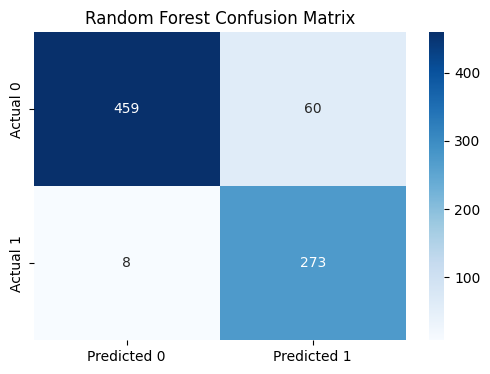

In [119]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [120]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="importance", ascending=False)
print(feature_importance)

                   feature  importance
0  vitamin_b12_percent_rda    0.723845
1         iron_percent_rda    0.122738
2                      bmi    0.082601
3                      age    0.070816


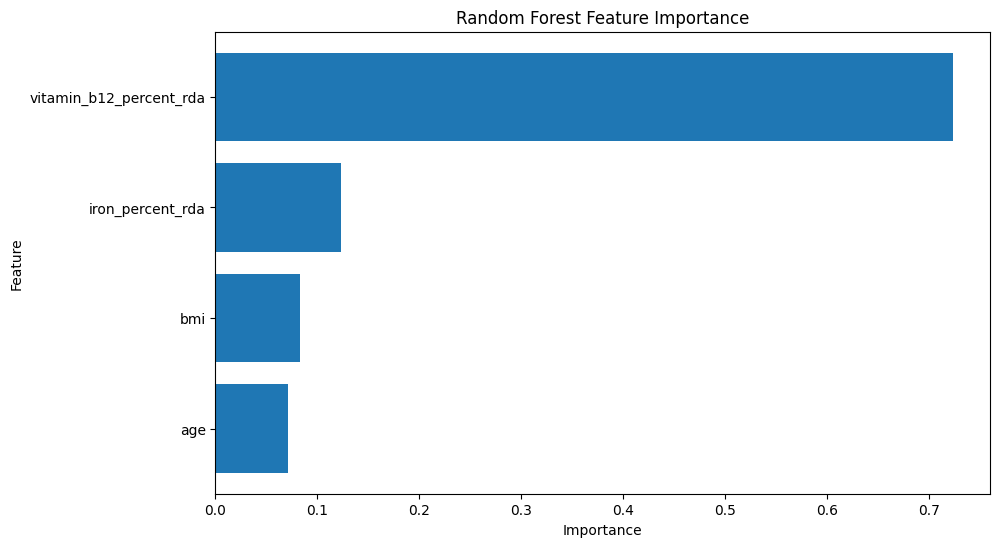

In [121]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [122]:
logistic_coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

logistic_coefficients = logistic_coefficients.sort_values(by="coefficient", ascending=False)
print(logistic_coefficients)

                   feature  coefficient
2                      bmi     0.023911
3                      age     0.004992
1         iron_percent_rda     0.001912
0  vitamin_b12_percent_rda    -0.103206


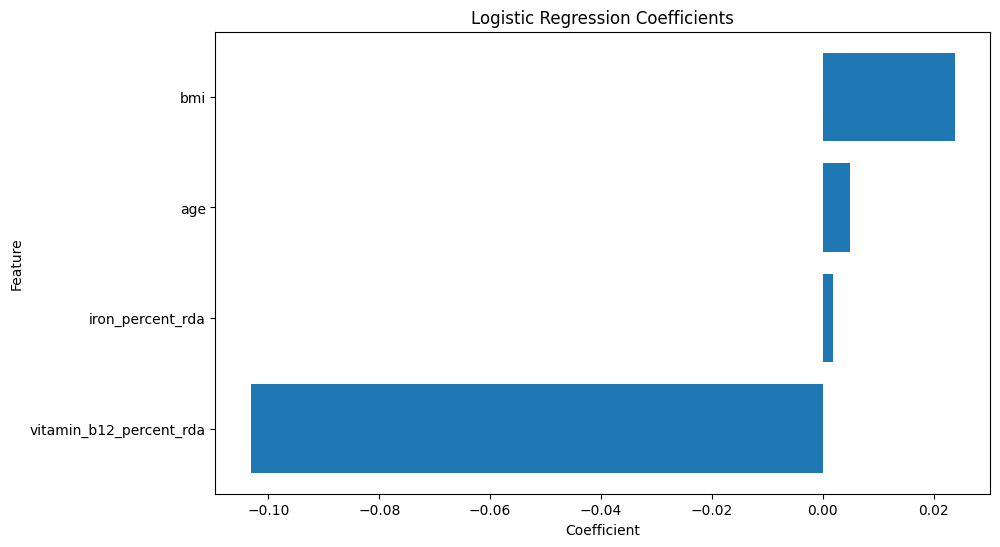

In [123]:
plt.figure(figsize=(10, 6))
plt.barh(logistic_coefficients["feature"], logistic_coefficients["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Coefficients")
plt.gca().invert_yaxis()
plt.show()

## Model Insights

The Random Forest model helped identify which health factors contributed most to predicting numbness. This made the project more than just a prediction task because it also provided insight into the drivers behind the outcome. Logistic Regression gave an interpretable baseline, while Random Forest offered a comparison model with feature importance analysis.

In [124]:
model_features = ["vitamin_b12_percent_rda", "iron_percent_rda", "bmi", "age"]

def predict_numbness(vitamin_b12_percent_rda, iron_percent_rda, bmi, age):
    input_df = pd.DataFrame([{
        "vitamin_b12_percent_rda": vitamin_b12_percent_rda,
        "iron_percent_rda": iron_percent_rda,
        "bmi": bmi,
        "age": age
    }])

    prediction = rf_model.predict(input_df)[0]
    probability = rf_model.predict_proba(input_df)[0][1]

    if prediction == 1:
        label = "High likelihood of numbness"
    else:
        label = "Low likelihood of numbness"

    return label, probability

In [125]:
label, probability = predict_numbness(
    vitamin_b12_percent_rda=30,
    iron_percent_rda=40,
    bmi=28,
    age=35
)

print("Prediction:", label)
print("Probability:", round(probability, 3))

Prediction: High likelihood of numbness
Probability: 0.79


In [126]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(model_features, "model_features.pkl")

print("Saved files successfully")

Saved files successfully


## Results
The project used Logistic Regression and Random Forest to predict numbness risk based on vitamin B12, iron, BMI, and age.
Random Forest performed better than Logistic Regression on the test set. Feature importance showed that vitamin B12 percent of recommended daily allowance was the most important predictor in the model.
This project demonstrates data analysis, feature engineering, classification modeling, and model interpretation in a health-related prediction task.

## Future Work
This approach can be extended by improving model performance, adding more health related features, and deploying the model as a web application for realtime predictions. 